# Zomato Rating Predictor
## Notebook 2 — Exploratory Data Analysis

**Objective:** Understand the cleaned dataset visually before modelling. Every chart here answers a business question and informs a feature decision in Notebook 3.

**Input:** `zomato_clean.csv` (output of Notebook 1)

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'DejaVu Sans'
})

TEAL   = '#0F6E56'
GOLD   = '#C8960C'
CORAL  = '#D85A30'
NAVY   = '#1B3A5C'
GREY   = '#888780'

print('Setup complete.')

Setup complete.


---
## 1. Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/zomato-rating-predictor/data/zomato_clean.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Mounted at /content/drive
Shape: (7403, 28)
Columns: ['Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Price range', 'Aggregate rating', 'Votes', 'cuisine_count', 'is_multi_cuisine', 'log_votes', 'cost_per_person', 'has_both_services', 'country_Australia', 'country_Brazil', 'country_Canada', 'country_India', 'country_Indonesia', 'country_New Zealand', 'country_Philippines', 'country_Qatar', 'country_Singapore', 'country_South Africa', 'country_Sri Lanka', 'country_Turkey', 'country_UAE', 'country_United Kingdom', 'country_United States', 'cuisine_freq_enc', 'city_freq_enc']


,Average Cost for two,Has Table booking,Has Online delivery,Price range,Aggregate rating,Votes,cuisine_count,is_multi_cuisine,log_votes,cost_per_person,...,country_Qatar,country_Singapore,country_South Africa,country_Sri Lanka,country_Turkey,country_UAE,country_United Kingdom,country_United States,cuisine_freq_enc,city_freq_enc
0,1100,1,0,3,4.8,314,3,1,5.752573,550.0,...,False,False,False,False,False,False,False,False,0.001891,0.00027
1,1200,1,0,3,4.5,591,1,0,6.383507,600.0,...,False,False,False,False,False,False,False,False,0.009591,0.00027
2,4000,1,0,4,4.4,270,4,1,5.602119,2000.0,...,False,False,False,False,False,False,False,False,0.006484,0.00054
3,1500,0,0,4,4.9,365,2,1,5.902633,750.0,...,False,False,False,False,False,False,False,False,0.009591,0.00054
4,1500,1,0,4,4.8,229,2,1,5.438079,750.0,...,False,False,False,False,False,False,False,False,0.009591,0.00054


In [4]:
# Quick statistical summary
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Average Cost for two,7403.0,1448.415,18303.524,0.000,300.000,500.000,800.000,800000.000
Has Table booking,7403.0,0.150,0.357,0.000,0.000,0.000,0.000,1.000
Has Online delivery,7403.0,0.318,0.466,0.000,0.000,0.000,1.000,1.000
Price range,7403.0,1.970,0.931,1.000,1.000,2.000,3.000,4.000
Aggregate rating,7403.0,3.440,0.552,1.800,3.000,3.400,3.800,4.900
Votes,7403.0,202.185,479.195,4.000,19.000,60.000,181.000,10934.000
cuisine_count,7403.0,2.199,1.135,1.000,1.000,2.000,3.000,8.000
is_multi_cuisine,7403.0,0.698,0.459,0.000,0.000,1.000,1.000,1.000
log_votes,7403.0,4.158,1.493,1.609,2.996,4.111,5.204,9.300
cost_per_person,7403.0,724.208,9151.762,0.000,150.000,250.000,400.000,400000.000


---
## 2. Target Variable — Aggregate Rating Distribution

**Question:** What does the rating distribution look like after removing unrated restaurants? Is it roughly normal or skewed?

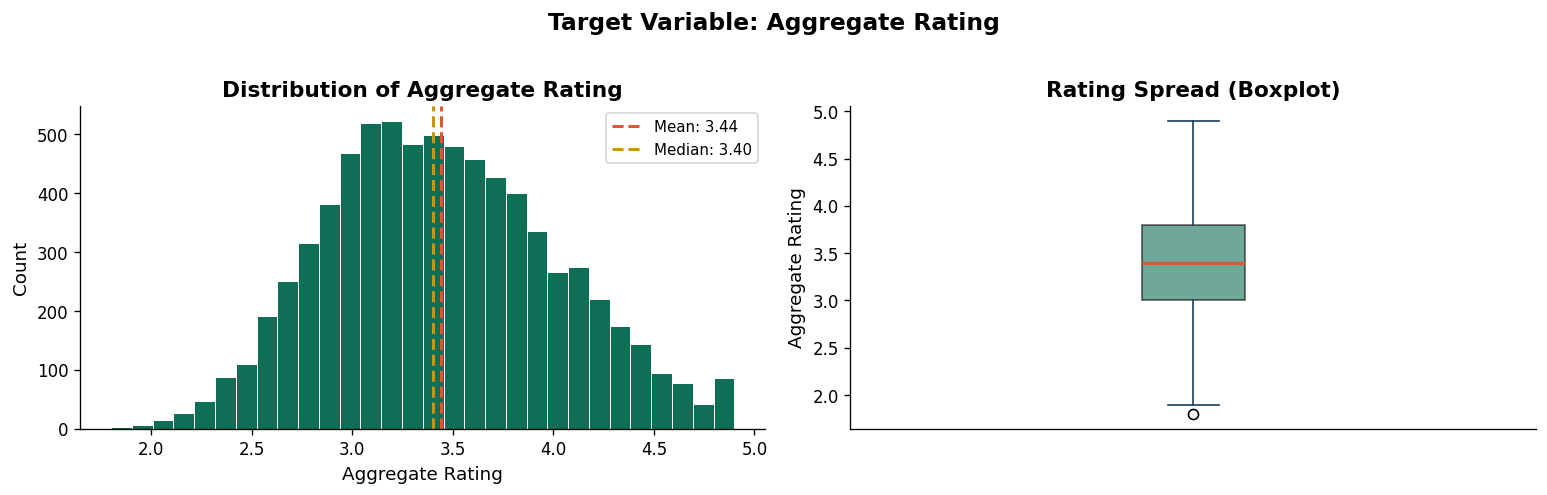

Mean:   3.440
Median: 3.400
Std:    0.552
Skew:   0.231


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: Histogram ────────────────────────────────────────────────────────
axes[0].hist(
    df['Aggregate rating'], bins=30,
    color=TEAL, edgecolor='white', linewidth=0.6
)
axes[0].set_title('Distribution of Aggregate Rating')
axes[0].set_xlabel('Aggregate Rating')
axes[0].set_ylabel('Count')
axes[0].axvline(df['Aggregate rating'].mean(), color=CORAL, lw=1.8,
                linestyle='--', label=f'Mean: {df["Aggregate rating"].mean():.2f}')
axes[0].axvline(df['Aggregate rating'].median(), color=GOLD, lw=1.8,
                linestyle='--', label=f'Median: {df["Aggregate rating"].median():.2f}')
axes[0].legend(fontsize=9)

# ── Right: Boxplot ─────────────────────────────────────────────────────────
axes[1].boxplot(
    df['Aggregate rating'], vert=True,
    patch_artist=True,
    boxprops=dict(facecolor=TEAL, alpha=0.6),
    medianprops=dict(color=CORAL, linewidth=2),
    whiskerprops=dict(color=NAVY),
    capprops=dict(color=NAVY)
)
axes[1].set_title('Rating Spread (Boxplot)')
axes[1].set_ylabel('Aggregate Rating')
axes[1].set_xticks([])

plt.suptitle('Target Variable: Aggregate Rating', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_rating_distribution.png', bbox_inches='tight')
plt.show()

print(f'Mean:   {df["Aggregate rating"].mean():.3f}')
print(f'Median: {df["Aggregate rating"].median():.3f}')
print(f'Std:    {df["Aggregate rating"].std():.3f}')
print(f'Skew:   {df["Aggregate rating"].skew():.3f}')

---
## 3. Ratings by Country

**Question:** Do ratings differ significantly across countries? This informs whether country features will add predictive power.

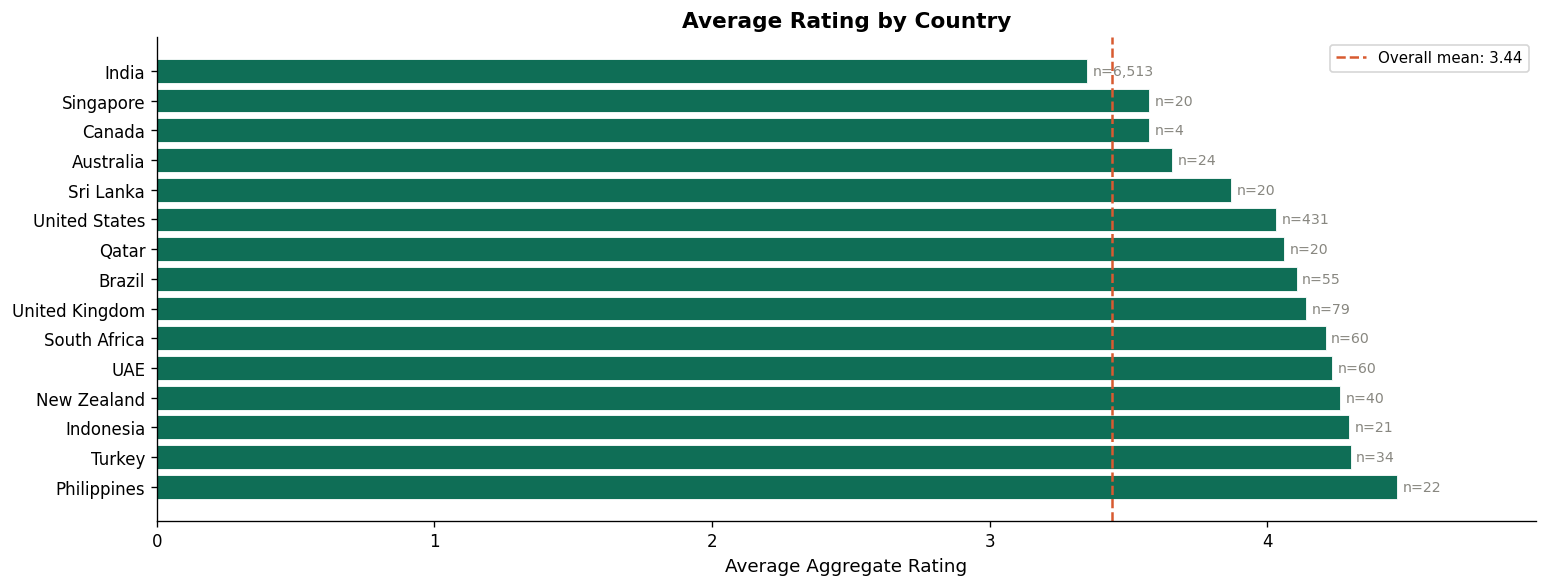

In [6]:
# Reconstruct country name from one-hot columns for plotting
country_cols = [c for c in df.columns if c.startswith('country_')]
df['country_label'] = df[country_cols].idxmax(axis=1).str.replace('country_', '', regex=False)

country_stats = (
    df.groupby('country_label')['Aggregate rating']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.barh(
    country_stats['country_label'],
    country_stats['mean'],
    color=TEAL, edgecolor='white', linewidth=0.5
)

# Annotate with restaurant count
for bar, count in zip(bars, country_stats['count']):
    ax.text(
        bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
        f'n={count:,}', va='center', ha='left', fontsize=8.5, color=GREY
    )

ax.axvline(df['Aggregate rating'].mean(), color=CORAL, lw=1.5,
           linestyle='--', label=f'Overall mean: {df["Aggregate rating"].mean():.2f}')
ax.set_title('Average Rating by Country')
ax.set_xlabel('Average Aggregate Rating')
ax.set_xlim(0, country_stats['mean'].max() + 0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_02_rating_by_country.png', bbox_inches='tight')
plt.show()

---
## 4. Votes vs Rating

**Question:** Is there a relationship between how many votes a restaurant has received and its rating? This validates our `log_votes` feature.

Correlation — raw votes vs rating:  0.409
Correlation — log votes vs rating:  0.649


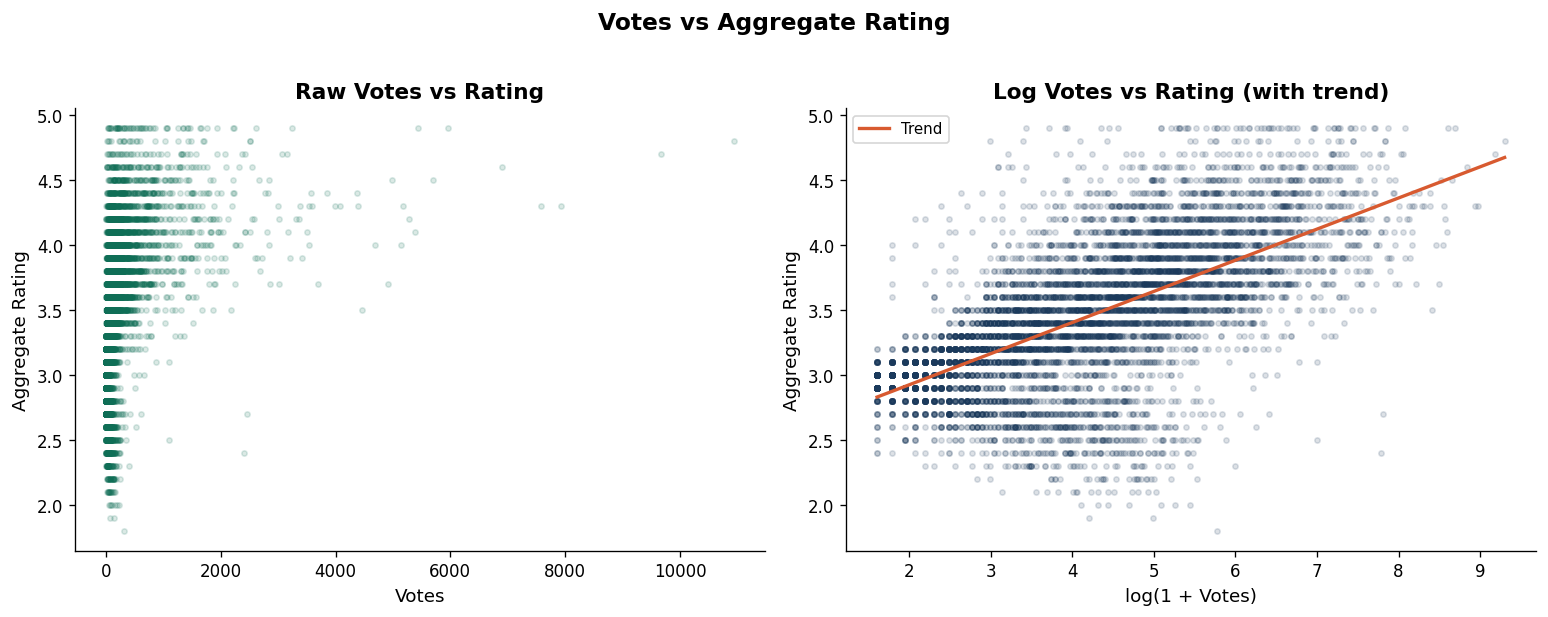

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Raw Votes ────────────────────────────────────────────────────────
axes[0].scatter(
    df['Votes'], df['Aggregate rating'],
    alpha=0.15, s=10, color=TEAL
)
axes[0].set_title('Raw Votes vs Rating')
axes[0].set_xlabel('Votes')
axes[0].set_ylabel('Aggregate Rating')

# ── Right: Log Votes ───────────────────────────────────────────────────────
axes[1].scatter(
    df['log_votes'], df['Aggregate rating'],
    alpha=0.15, s=10, color=NAVY
)

# Trend line
z = np.polyfit(df['log_votes'], df['Aggregate rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['log_votes'].min(), df['log_votes'].max(), 200)
axes[1].plot(x_line, p(x_line), color=CORAL, lw=2, label='Trend')
axes[1].set_title('Log Votes vs Rating (with trend)')
axes[1].set_xlabel('log(1 + Votes)')
axes[1].set_ylabel('Aggregate Rating')
axes[1].legend(fontsize=9)

corr_raw = df['Votes'].corr(df['Aggregate rating'])
corr_log = df['log_votes'].corr(df['Aggregate rating'])
print(f'Correlation — raw votes vs rating:  {corr_raw:.3f}')
print(f'Correlation — log votes vs rating:  {corr_log:.3f}')

plt.suptitle('Votes vs Aggregate Rating', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_03_votes_vs_rating.png', bbox_inches='tight')
plt.show()

---
## 5. Rating by Price Range

**Question:** Do more expensive restaurants consistently get higher ratings, or is it more nuanced?

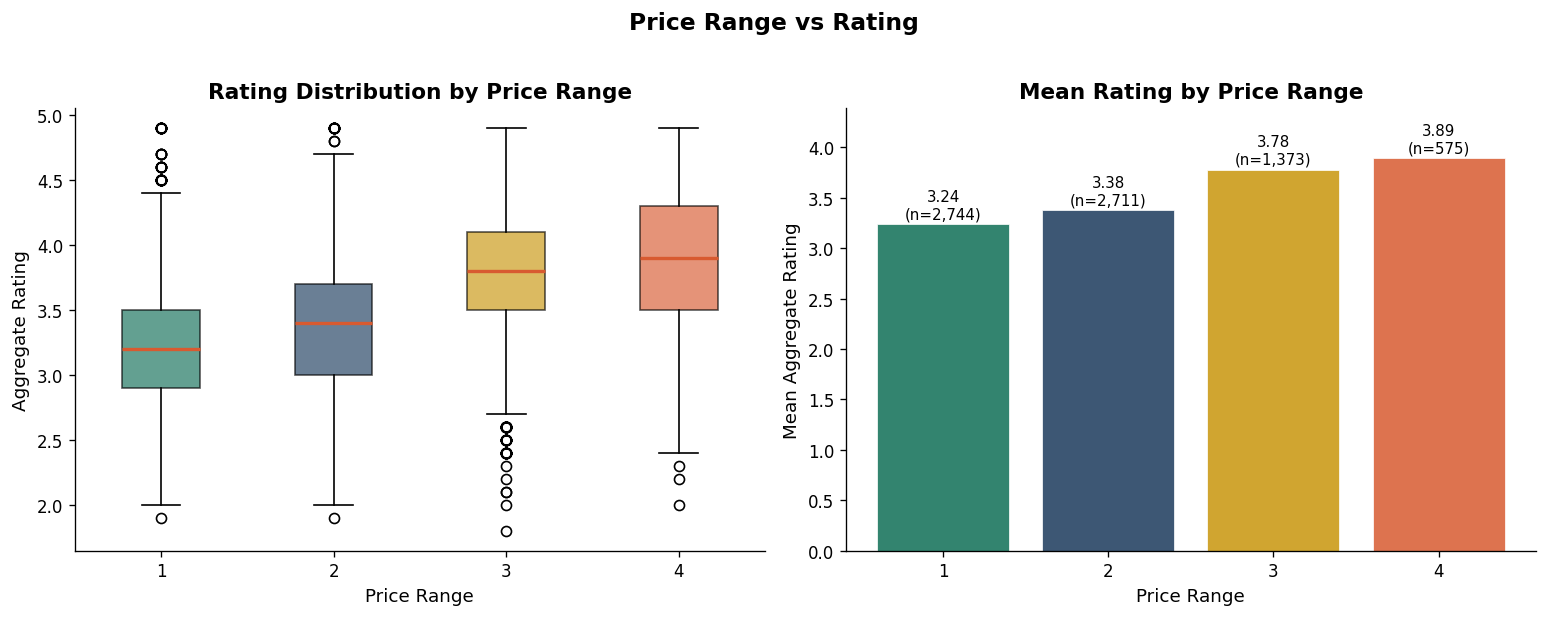

In [8]:
price_labels = {1: '1 — Budget', 2: '2 — Moderate', 3: '3 — Expensive', 4: '4 — Luxury'}
df['price_label'] = df['Price range'].map(price_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Boxplot ──────────────────────────────────────────────────────────
price_order = list(price_labels.values())
data_by_price = [df[df['price_label'] == p]['Aggregate rating'].dropna() for p in price_order]

bp = axes[0].boxplot(
    data_by_price,
    patch_artist=True,
    labels=[str(i+1) for i in range(4)],
    medianprops=dict(color=CORAL, linewidth=2)
)
colors = [TEAL, NAVY, GOLD, CORAL]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

axes[0].set_title('Rating Distribution by Price Range')
axes[0].set_xlabel('Price Range')
axes[0].set_ylabel('Aggregate Rating')

# ── Right: Mean + count bar ────────────────────────────────────────────────
price_stats = (
    df.groupby('Price range')['Aggregate rating']
    .agg(['mean', 'count'])
    .reset_index()
)

bars = axes[1].bar(
    price_stats['Price range'].astype(str),
    price_stats['mean'],
    color=colors, edgecolor='white', linewidth=0.5, alpha=0.85
)
for bar, (_, row) in zip(bars, price_stats.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.03,
        f'{row["mean"]:.2f}\n(n={int(row["count"]):,})',
        ha='center', va='bottom', fontsize=9
    )
axes[1].set_title('Mean Rating by Price Range')
axes[1].set_xlabel('Price Range')
axes[1].set_ylabel('Mean Aggregate Rating')
axes[1].set_ylim(0, price_stats['mean'].max() + 0.5)

plt.suptitle('Price Range vs Rating', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_04_price_vs_rating.png', bbox_inches='tight')
plt.show()

---
## 6. Online Delivery & Table Booking vs Rating

**Question:** Do restaurants with online delivery or table booking rate higher? This was our original hypothesis — now let's visualise it properly on clean data.

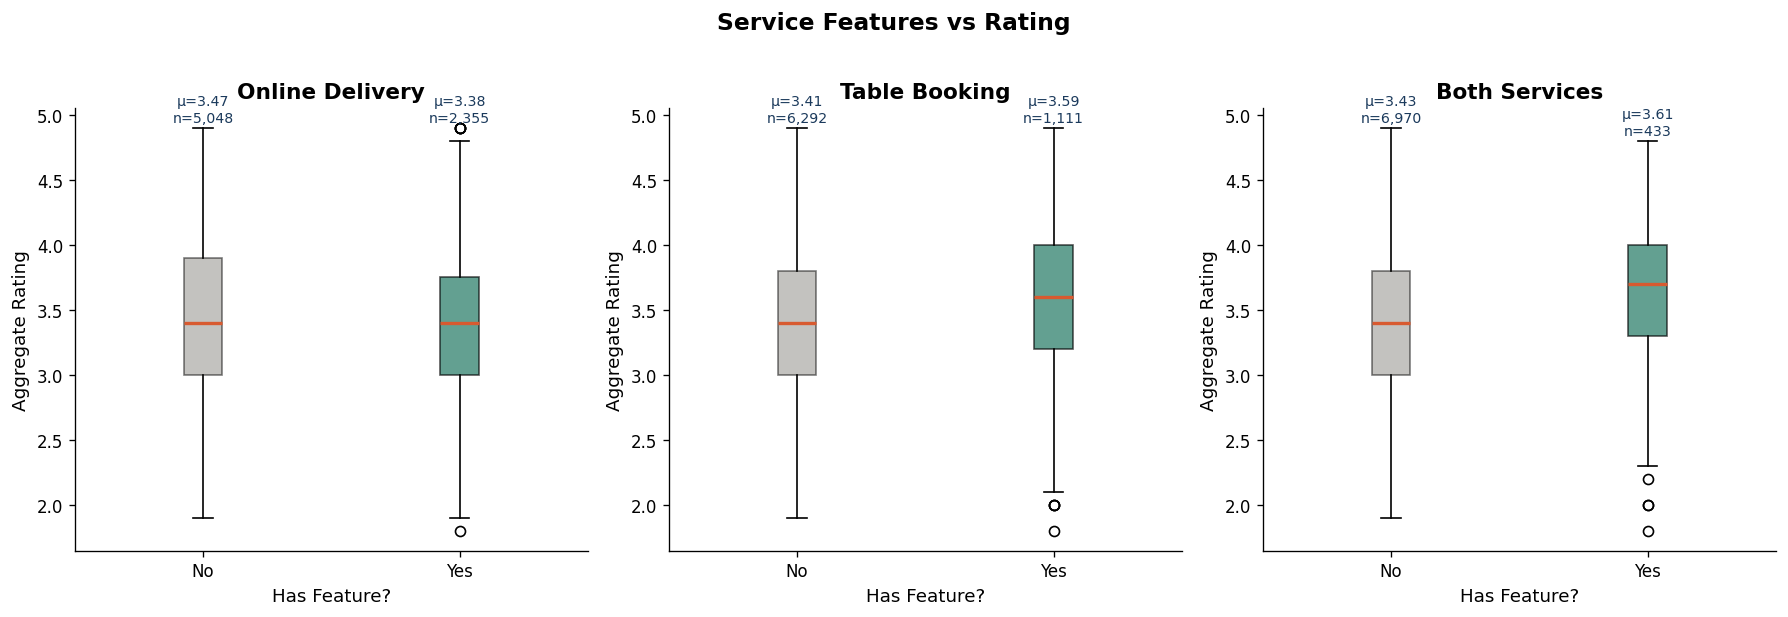

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

service_scenarios = [
    ('Has Online delivery', 'Online Delivery', axes[0]),
    ('Has Table booking',   'Table Booking',   axes[1]),
    ('has_both_services',   'Both Services',   axes[2]),
]

for col, label, ax in service_scenarios:
    groups = [df[df[col] == 0]['Aggregate rating'],
              df[df[col] == 1]['Aggregate rating']]
    bp = ax.boxplot(
        groups, patch_artist=True,
        labels=['No', 'Yes'],
        medianprops=dict(color=CORAL, linewidth=2)
    )
    bp['boxes'][0].set_facecolor(GREY);  bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor(TEAL);  bp['boxes'][1].set_alpha(0.65)

    for i, g in enumerate(groups):
        ax.text(i+1, g.max() + 0.05, f'μ={g.mean():.2f}\nn={len(g):,}',
                ha='center', fontsize=8.5, color=NAVY)

    ax.set_title(f'{label}')
    ax.set_xlabel('Has Feature?')
    ax.set_ylabel('Aggregate Rating')

plt.suptitle('Service Features vs Rating', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_05_services_vs_rating.png', bbox_inches='tight')
plt.show()

---
## 7. Top 20 Cities by Restaurant Count

**Question:** Where is the dataset geographically concentrated? This matters for interpreting city frequency encoding.

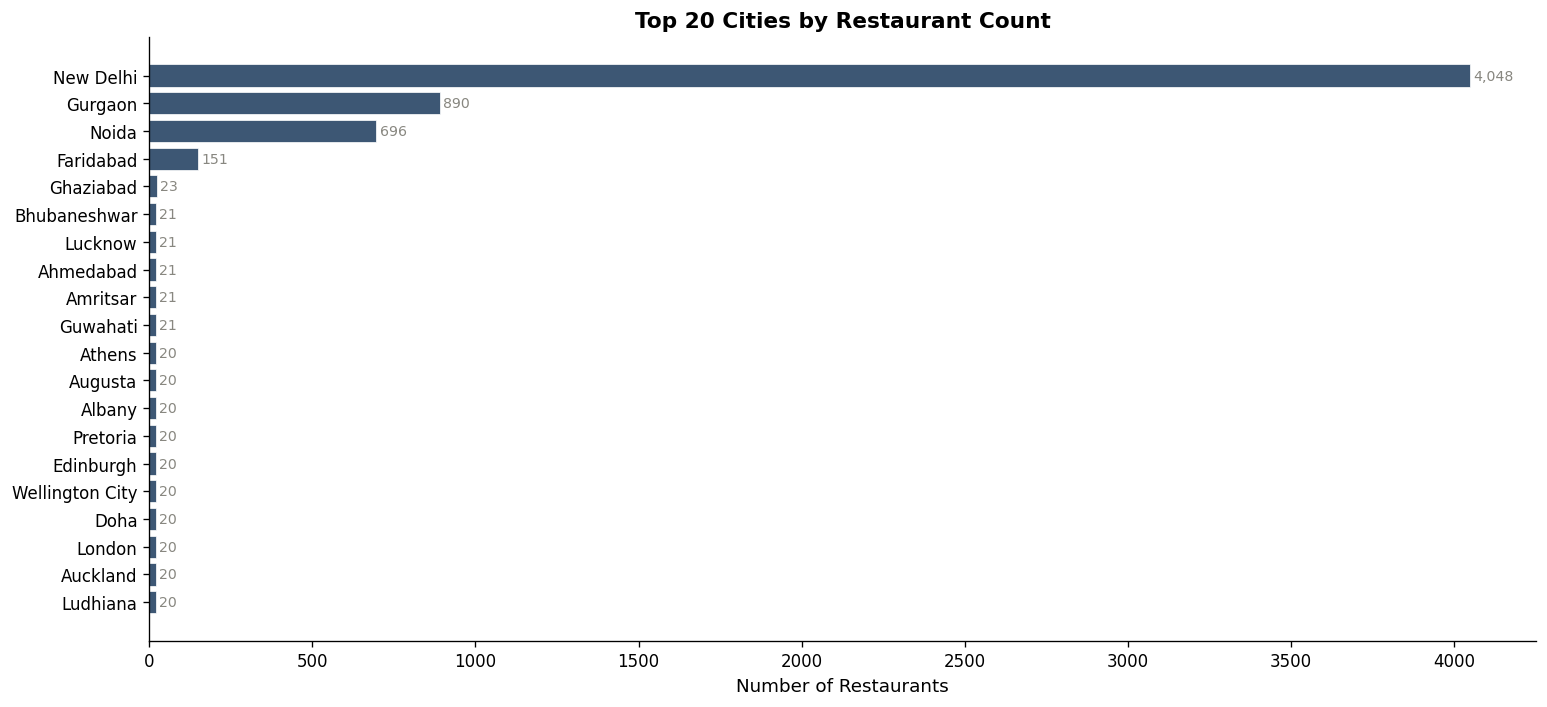

In [11]:
# Reconstruct city frequency from city_freq_enc
# We'll use the original raw file for city names
raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/zomato-rating-predictor/data/zomato.csv', encoding='latin1')
raw = raw[raw['Aggregate rating'] > 0].drop_duplicates()

city_counts = raw['City'].value_counts().head(20).reset_index()
city_counts.columns = ['City', 'Count']

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.barh(
    city_counts['City'][::-1],
    city_counts['Count'][::-1],
    color=NAVY, edgecolor='white', linewidth=0.5, alpha=0.85
)

for bar, val in zip(bars, city_counts['Count'][::-1]):
    ax.text(
        bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
        f'{val:,}', va='center', ha='left', fontsize=8.5, color=GREY
    )

ax.set_title('Top 20 Cities by Restaurant Count')
ax.set_xlabel('Number of Restaurants')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('plot_06_top_cities.png', bbox_inches='tight')
plt.show()

---
## 8. Top Cuisines by Average Rating

**Question:** Which primary cuisines consistently score highest? A minimum threshold of restaurants is applied to avoid small-sample noise.

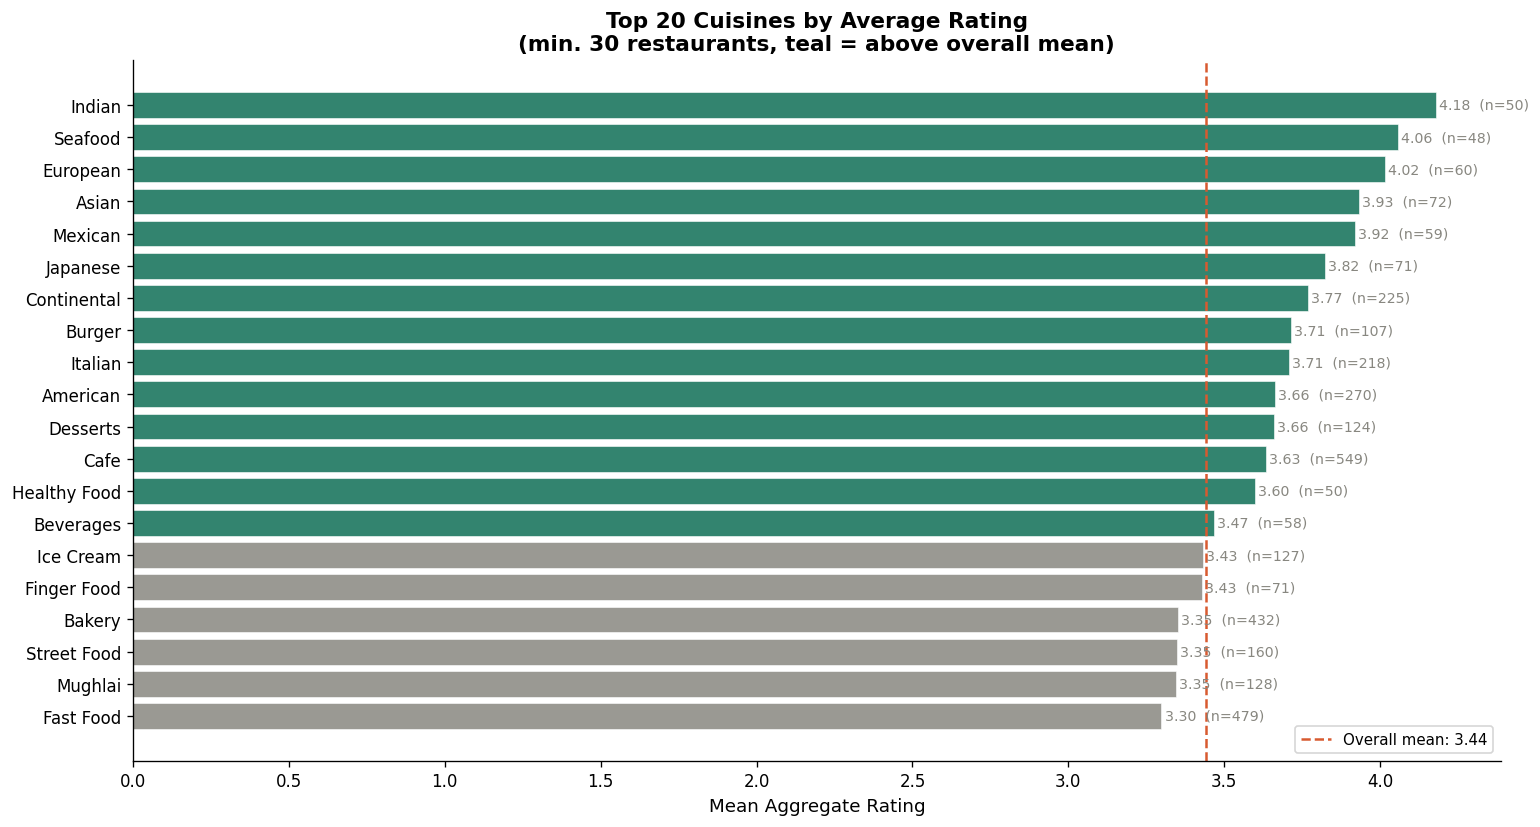

In [12]:
# Reconstruct primary_cuisine from the raw file for labelling
raw['primary_cuisine'] = raw['Cuisines'].fillna('Unknown').str.split(',').str[0].str.strip()

cuisine_stats = (
    raw.groupby('primary_cuisine')['Aggregate rating']
    .agg(['mean', 'count'])
    .reset_index()
)

# Minimum 30 restaurants to be included (avoid noise from rare cuisines)
cuisine_stats = cuisine_stats[cuisine_stats['count'] >= 30].sort_values('mean', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(13, 7))

bar_colors = [TEAL if m >= raw['Aggregate rating'].mean() else GREY
              for m in cuisine_stats['mean']]

bars = ax.barh(
    cuisine_stats['primary_cuisine'][::-1],
    cuisine_stats['mean'][::-1],
    color=bar_colors[::-1], edgecolor='white', linewidth=0.4, alpha=0.85
)

for bar, (_, row) in zip(bars, cuisine_stats[::-1].iterrows()):
    ax.text(
        bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
        f'{row["mean"]:.2f}  (n={int(row["count"]):,})',
        va='center', ha='left', fontsize=8.5, color=GREY
    )

ax.axvline(raw['Aggregate rating'].mean(), color=CORAL, lw=1.5,
           linestyle='--', label=f'Overall mean: {raw["Aggregate rating"].mean():.2f}')
ax.set_title('Top 20 Cuisines by Average Rating\n(min. 30 restaurants, teal = above overall mean)')
ax.set_xlabel('Mean Aggregate Rating')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_07_cuisine_ratings.png', bbox_inches='tight')
plt.show()

---
## 9. Correlation Heatmap

**Question:** Which numeric features have the strongest linear relationship with `Aggregate rating`? This previews what SHAP will confirm later.

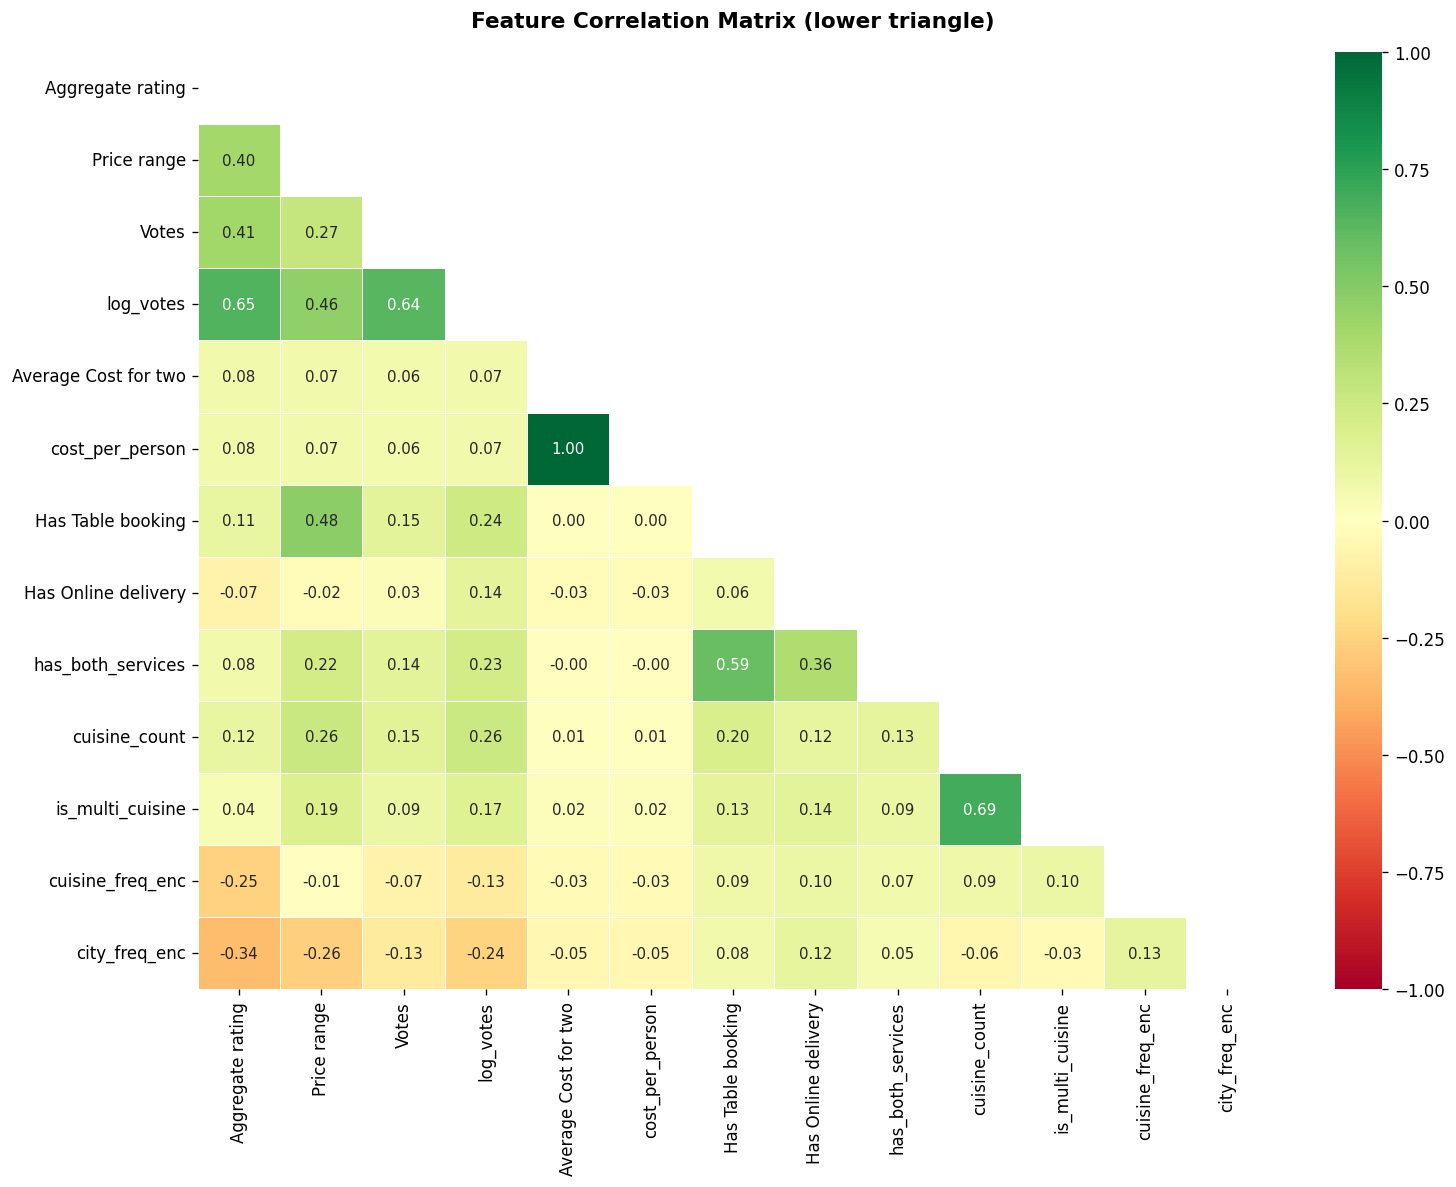


=== Correlation with Aggregate Rating ===
log_votes               0.649
Votes                   0.409
Price range             0.403
city_freq_enc          -0.340
cuisine_freq_enc       -0.254
cuisine_count           0.115
Has Table booking       0.112
has_both_services       0.078
Average Cost for two    0.077
cost_per_person         0.077
Has Online delivery    -0.073
is_multi_cuisine        0.040


In [13]:
# Use only the core numeric features (exclude country dummies for readability)
core_cols = [
    'Aggregate rating', 'Price range', 'Votes', 'log_votes',
    'Average Cost for two', 'cost_per_person',
    'Has Table booking', 'Has Online delivery', 'has_both_services',
    'cuisine_count', 'is_multi_cuisine',
    'cuisine_freq_enc', 'city_freq_enc'
]

corr = df[core_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax, annot_kws={'size': 9}
)
ax.set_title('Feature Correlation Matrix (lower triangle)', pad=15)
plt.tight_layout()
plt.savefig('plot_08_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print correlation with target specifically
print('\n=== Correlation with Aggregate Rating ===')
target_corr = corr['Aggregate rating'].drop('Aggregate rating').sort_values(key=abs, ascending=False)
print(target_corr.round(3).to_string())

---
## 10. Multi-Cuisine vs Single-Cuisine Rating

**Question:** Does offering more cuisines help or hurt a restaurant's rating?

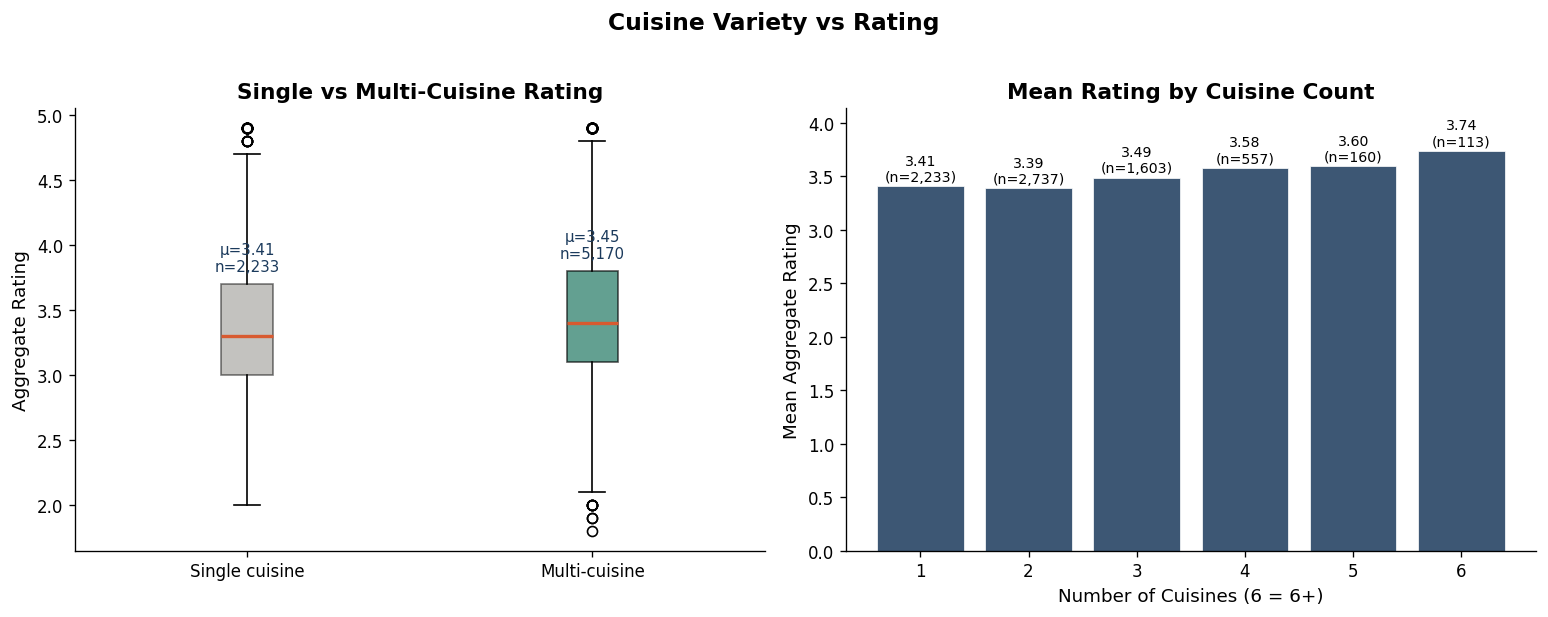

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Single vs multi-cuisine boxplot ─────────────────────────────────
groups = [df[df['is_multi_cuisine'] == 0]['Aggregate rating'],
          df[df['is_multi_cuisine'] == 1]['Aggregate rating']]
bp = axes[0].boxplot(
    groups, patch_artist=True,
    labels=['Single cuisine', 'Multi-cuisine'],
    medianprops=dict(color=CORAL, linewidth=2)
)
bp['boxes'][0].set_facecolor(GREY);  bp['boxes'][0].set_alpha(0.5)
bp['boxes'][1].set_facecolor(TEAL);  bp['boxes'][1].set_alpha(0.65)

for i, g in enumerate(groups):
    axes[0].text(i+1, g.quantile(0.75) + 0.1,
                 f'μ={g.mean():.2f}\nn={len(g):,}',
                 ha='center', fontsize=9, color=NAVY)

axes[0].set_title('Single vs Multi-Cuisine Rating')
axes[0].set_ylabel('Aggregate Rating')

# ── Right: Rating by cuisine count (1–6+) ─────────────────────────────────
df['cuisine_bucket'] = df['cuisine_count'].clip(upper=6)
bucket_means = df.groupby('cuisine_bucket')['Aggregate rating'].mean()
bucket_counts = df.groupby('cuisine_bucket')['Aggregate rating'].count()

bars = axes[1].bar(
    bucket_means.index.astype(str),
    bucket_means.values,
    color=NAVY, edgecolor='white', linewidth=0.5, alpha=0.85
)

for bar, (idx, mean_val) in zip(bars, bucket_means.items()):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{mean_val:.2f}\n(n={bucket_counts[idx]:,})',
        ha='center', va='bottom', fontsize=8.5
    )

axes[1].set_title('Mean Rating by Cuisine Count')
axes[1].set_xlabel('Number of Cuisines (6 = 6+)')
axes[1].set_ylabel('Mean Aggregate Rating')
axes[1].set_ylim(0, bucket_means.max() + 0.4)

plt.suptitle('Cuisine Variety vs Rating', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_09_cuisine_variety.png', bbox_inches='tight')
plt.show()

---
## 11. EDA Summary — Key Findings

In [15]:
print('=' * 60)
print('EDA SUMMARY — KEY FINDINGS')
print('=' * 60)

print(f"""
1. TARGET DISTRIBUTION
   Mean rating: {df['Aggregate rating'].mean():.2f}
   Std:         {df['Aggregate rating'].std():.2f}
   Range:       {df['Aggregate rating'].min():.1f} – {df['Aggregate rating'].max():.1f}
   Slight negative skew — most restaurants cluster around 3.0–4.0

2. VOTES
   Correlation (raw votes vs rating):  {df['Votes'].corr(df['Aggregate rating']):.3f}
   Correlation (log votes vs rating):  {df['log_votes'].corr(df['Aggregate rating']):.3f}
   → log_votes is a stronger feature than raw Votes

3. SERVICES
   Mean rating WITH table booking:    {df[df['Has Table booking']==1]['Aggregate rating'].mean():.2f}
   Mean rating WITHOUT table booking: {df[df['Has Table booking']==0]['Aggregate rating'].mean():.2f}
   Mean rating WITH online delivery:  {df[df['Has Online delivery']==1]['Aggregate rating'].mean():.2f}
   Mean rating WITHOUT online delivery: {df[df['Has Online delivery']==0]['Aggregate rating'].mean():.2f}
   Mean rating WITH both services:    {df[df['has_both_services']==1]['Aggregate rating'].mean():.2f}
   → Hypothesis confirmed: service features positively correlated with rating

4. PRICE RANGE
   Clear positive trend: higher price range → higher average rating
   Budget restaurants (1) underperform luxury (4) significantly

5. GEOGRAPHY
   Dataset is heavily India-dominated (~75% of records after cleaning)
   Country-level encoding will help but model should be interpreted accordingly
""")

print('=== NOTEBOOK 2 COMPLETE ===')
print('Next: Run 03_modelling_and_shap.ipynb')

EDA SUMMARY — KEY FINDINGS

1. TARGET DISTRIBUTION
   Mean rating: 3.44
   Std:         0.55
   Range:       1.8 – 4.9
   Slight negative skew — most restaurants cluster around 3.0–4.0

2. VOTES
   Correlation (raw votes vs rating):  0.409
   Correlation (log votes vs rating):  0.649
   → log_votes is a stronger feature than raw Votes

3. SERVICES
   Mean rating WITH table booking:    3.59
   Mean rating WITHOUT table booking: 3.41
   Mean rating WITH online delivery:  3.38
   Mean rating WITHOUT online delivery: 3.47
   Mean rating WITH both services:    3.61
   → Hypothesis confirmed: service features positively correlated with rating

4. PRICE RANGE
   Clear positive trend: higher price range → higher average rating
   Budget restaurants (1) underperform luxury (4) significantly

5. GEOGRAPHY
   Dataset is heavily India-dominated (~75% of records after cleaning)
   Country-level encoding will help but model should be interpreted accordingly

=== NOTEBOOK 2 COMPLETE ===
Next: Run 03_